In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t68.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t129.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t104.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t204.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t244.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t195.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t207.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t262.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel smut (sori creamy)t60.jpg
/kaggle/input/newdatasett/newdataset/val/Covered Kernel smut/Covered Kernel

In [2]:
!ls /kaggle/input
!ls /kaggle/input/newdatasett
!ls /kaggle/input/newdatasett/newdataset


newdatasett
newdataset
test  train  val


In [3]:
train_dir = "/kaggle/input/newdatasett/newdataset/train"
val_dir = "/kaggle/input/newdatasett/newdataset/val"
test_dir = "/kaggle/input/newdatasett/newdataset/test"

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize ImageDataGenerator
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load train, validation, and test data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)
print("Class indices:", train_generator.class_indices)


Found 5013 images belonging to 6 classes.
Found 1436 images belonging to 6 classes.
Found 718 images belonging to 6 classes.
Class indices: {'Anthracnose and Red Rot': 0, 'Cereal Grain molds': 1, 'Covered Kernel smut': 2, 'Head Smut': 3, 'Rust': 4, 'loose smut': 5}


In [4]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(train_generator.class_indices), activation='softmax')  # Output layer
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)


Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1732134373.709090      94 service.cc:145] XLA service 0x7f9e2000f490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1732134373.709165      94 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1732134373.709170      94 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  1/157 ━━━━━━━━━━━━━━━━━━━━ 50:15 19s/step - accuracy: 0.1875 - loss: 1.9183

I0000 00:00:1732134387.311991      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 638ms/step - accuracy: 0.3278 - loss: 1.7324 - val_accuracy: 0.5042 - val_loss: 1.2325
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 352ms/step - accuracy: 0.5023 - loss: 1.2436 - val_accuracy: 0.5801 - val_loss: 1.0688
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 339ms/step - accuracy: 0.5558 - loss: 1.0870 - val_accuracy: 0.6205 - val_loss: 0.9929
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 327ms/step - accuracy: 0.6015 - loss: 0.9629 - val_accuracy: 0.6630 - val_loss: 0.8260
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 329ms/step - accuracy: 0.6390 - loss: 0.8850 - val_accuracy: 0.6525 - val_loss: 0.8085
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.6481 - loss: 0.8296 - val_accuracy: 0.7061 - val_loss: 0.6977
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.7165 - loss: 0.6995 - val_accuracy: 0.7841 - val_loss: 0.5897
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 332ms/step - accuracy: 0.7128 - loss: 0.6917 - va

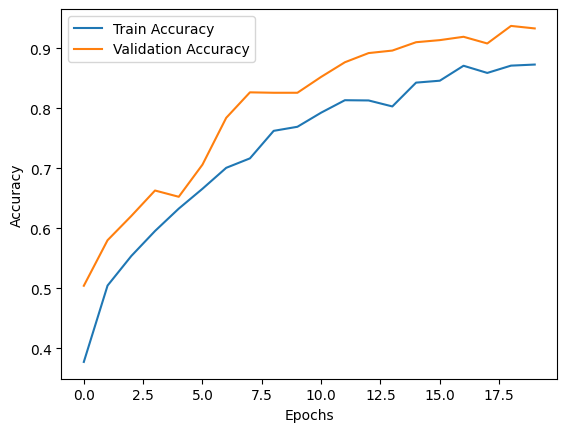

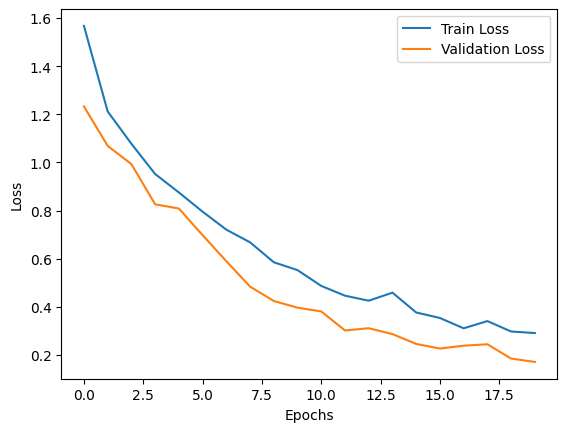

In [6]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [7]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - accuracy: 0.9340 - loss: 0.2307
Test Accuracy: 92.34%
Test Loss: 0.2393


In [8]:
model.save("sorghum_disease_model.h5")


In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to the test image
img_path = "/kaggle/input/newdatasett/newdataset/val/Anthracnose and Red Rot/AnthracnoseRed Rot165.jpg"

# Load the image and resize it to the model's input size
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)  # Convert to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize pixel values


In [10]:
# Predict the class
predictions = model.predict(img_array)

# Get the predicted class index
predicted_class_index = np.argmax(predictions)

# Map the index to the class name
class_names = train_generator.class_indices.keys()  # Replace `train_generator` with your data generator
predicted_class = list(class_names)[predicted_class_index]

print(f"Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
Predicted Class: Anthracnose and Red Rot


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


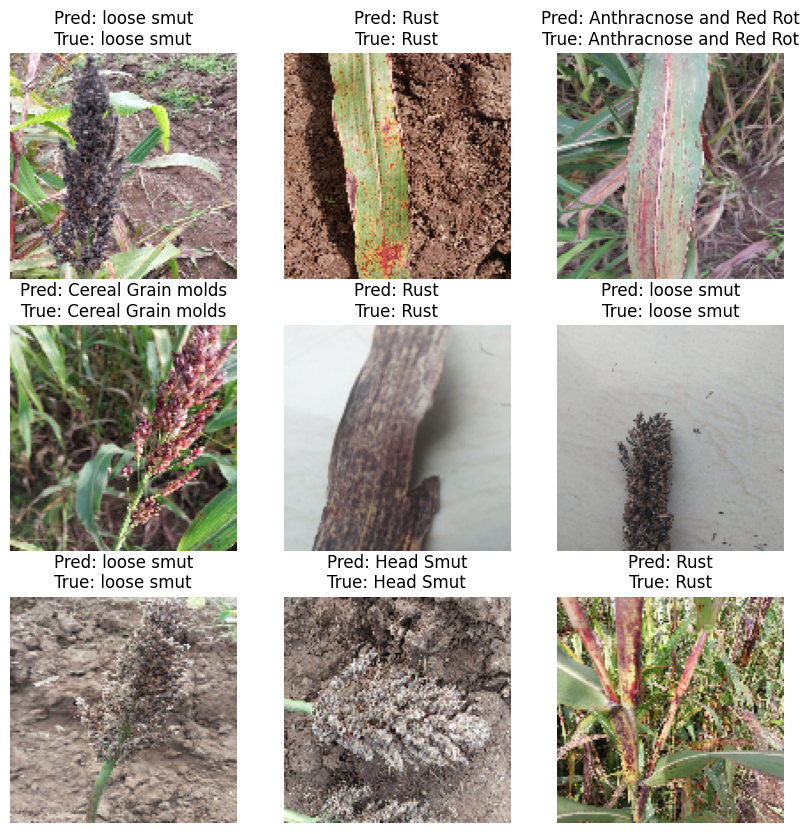

In [11]:
import matplotlib.pyplot as plt

# Test on a batch of test images
test_images, test_labels = next(test_generator)

# Predict on the test batch
predictions = model.predict(test_images)

# Plot the images with predicted and true labels
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(test_images[i])
    predicted_class = list(class_names)[np.argmax(predictions[i])]
    true_class = list(class_names)[np.argmax(test_labels[i])]
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}")
    plt.axis('off')
plt.show()


In [12]:
model.save("sorghum_disease_model.h5")